In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the dataset
df = pd.read_csv(r"Dataset.csv")

In [17]:
df.head()

,Content_Type,Title,Director,Cast,Country,Release_Date,Rating,Duration,Genres
0,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies"
2,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies"
3,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas


In [19]:
df.tail()

,Content_Type,Title,Director,Cast,Country,Release_Date,Rating,Duration,Genres
7784,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies"
7785,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals"
7786,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M..."
7787,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV"
7788,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals"


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Content_Type  7789 non-null   object
 1   Title         7789 non-null   object
 2   Director      5401 non-null   object
 3   Cast          7071 non-null   object
 4   Country       7282 non-null   object
 5   Release_Date  7779 non-null   object
 6   Rating        7782 non-null   object
 7   Duration      7789 non-null   object
 8   Genres        7789 non-null   object
dtypes: object(9)
memory usage: 547.8+ KB


In [23]:
# Rename columns for clarity
df = df.rename(columns={'Category': 'Content_Type', 'Type': 'Genres'})
df

,Content_Type,Title,Director,Cast,Country,Release_Date,Rating,Duration,Genres
0,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies"
2,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies"
3,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas
...,...,...,...,...,...,...,...,...,...
7784,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies"
7785,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals"
7786,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M..."
7787,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV"


In [29]:
# Handle missing values
df['Director'] = df['Director'].fillna('Unknown')
df['Cast'] = df['Cast'].fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna('Unknown')
df['Duration'] = df['Duration'].fillna('Unknown')

In [31]:
# Handle missing 'Release_Date' and convert to datetime
df.dropna(subset=['Release_Date'], inplace=True)
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df.dropna(subset=['Release_Date'], inplace=True) # Drop rows where conversion failed
df['Release_Year'] = df['Release_Date'].dt.year

In [33]:
df

,Content_Type,Title,Director,Cast,Country,Release_Date,Rating,Duration,Genres,Release_Year
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",2020
1,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",2016
2,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies",2018
3,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",2017
4,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,2020
...,...,...,...,...,...,...,...,...,...,...
7784,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,TV-MA,99 min,"Dramas, International Movies",2020
7785,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,TV-14,111 min,"Dramas, International Movies, Music & Musicals",2019
7786,Movie,Zulu Man in Japan,Unknown,Nasty C,Unknown,2020-09-25,TV-MA,44 min,"Documentaries, International Movies, Music & M...",2020
7787,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,TV-PG,1 Season,"International TV Shows, Reality TV",2020


In [41]:
# Save the preprocessed Dataset
df.to_csv('Preprocessed_Dataset.csv', index=False)
print("Data Preprocessing complete.")

Data Preprocessing complete.


In [47]:
# CONTENT TYPE DISTRIBUTION (Movies vs. TV Shows)
content_type_by_year = df.groupby(['Release_Year', 'Content_Type']).size().unstack(fill_value=0)
content_type_by_year = content_type_by_year[content_type_by_year.index >= 200]
content_type_by_year

Content_Type,Movie,TV Show
Release_Year,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,4
2014,19,5
2015,58,21
2016,258,174


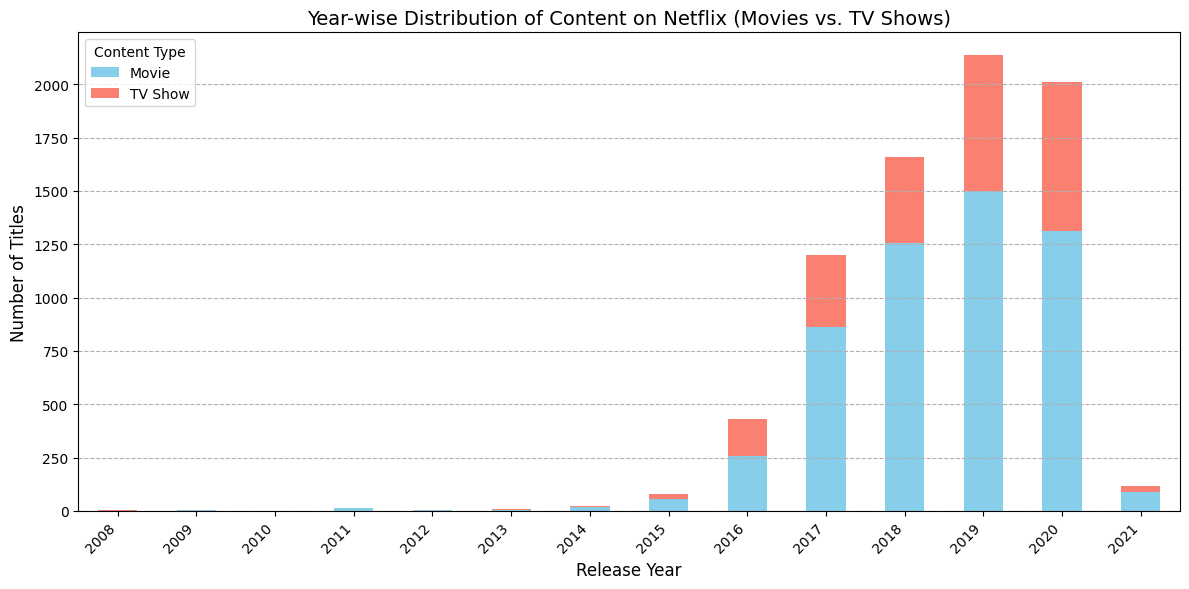

In [49]:
# Visualization: Year-wise Movies vs. TV Shows distribution
plt.figure(figsize=(12, 6))
content_type_by_year.plot(kind='bar', stacked=True, color={'Movie': 'skyblue', 'TV Show': 'salmon'}, ax=plt.gca())
plt.title('Year-wise Distribution of Content on Netflix (Movies vs. TV Shows)', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(title='Content Type')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [54]:
#GENRE TRENDS
df_genres = df.assign(Genres=df['Genres'].str.split(', ')).explode('Genres')
df_genres['Genres'] = df_genres['Genres'].str.strip()

In [56]:
top_10_genres = df_genres['Genres'].value_counts().nlargest(10).index.tolist()
df_top_genres = df_genres[df_genres['Genres'].isin(top_10_genres)]
genre_trend = df_top_genres.groupby(['Release_Year', 'Genres']).size().unstack(fill_value=0)
genre_trend = genre_trend[genre_trend.index >= 2010]

In [60]:
top_10_genres

['International Movies',
 'Dramas',
 'Comedies',
 'International TV Shows',
 'Documentaries',
 'Action & Adventure',
 'TV Dramas',
 'Independent Movies',
 'Children & Family Movies',
 'Romantic Movies']

In [62]:
genre_trend

Genres,Action & Adventure,Children & Family Movies,Comedies,Documentaries,Dramas,Independent Movies,International Movies,International TV Shows,Romantic Movies,TV Dramas
Release_Year,,,,,,,,,,
2011,0,1,0,0,13,0,1,0,0,0
2012,0,1,2,1,0,0,0,0,0,0
2013,0,2,1,1,0,0,0,1,0,3
2014,1,4,2,8,0,0,2,0,0,3
2015,2,11,12,13,12,7,10,3,1,4
2016,20,20,49,69,67,32,85,89,7,41
2017,106,77,191,206,297,116,418,198,68,127
2018,178,85,301,170,534,159,677,218,111,112
2019,222,148,452,189,597,206,641,355,157,192


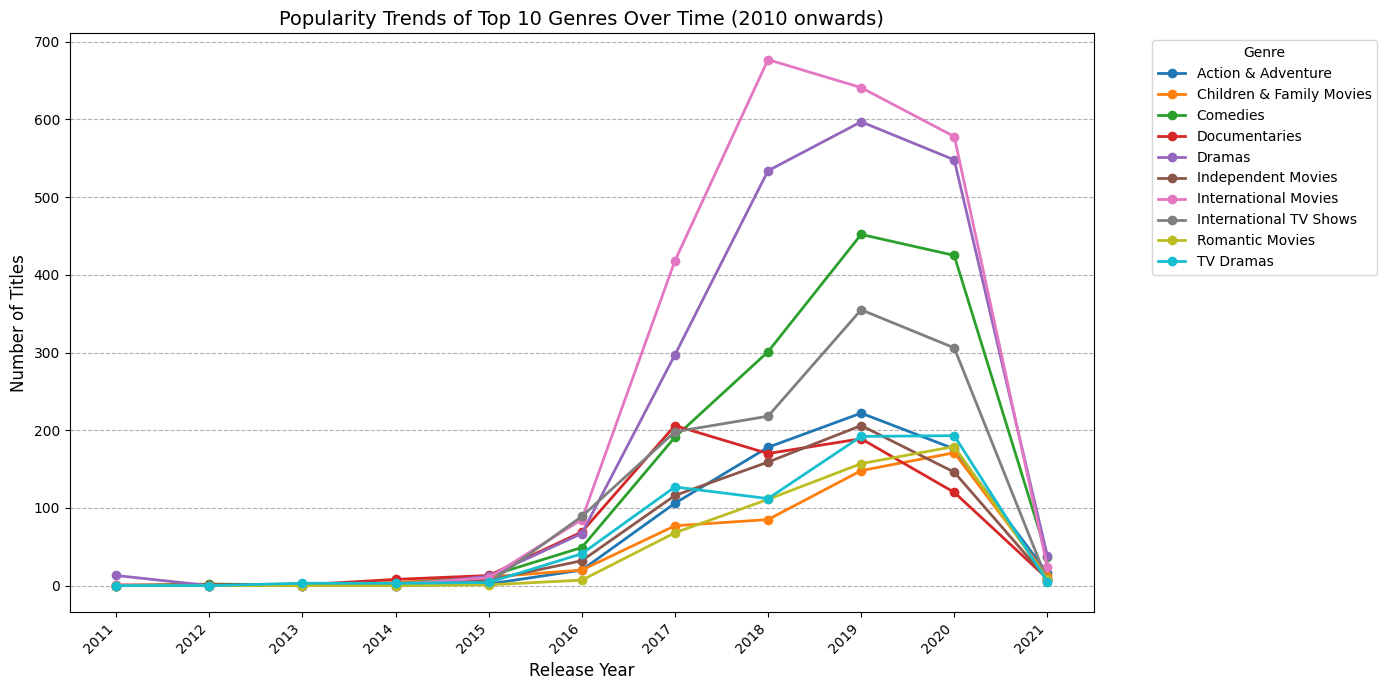

In [58]:
# Visualization: Genre popularity trends over time (Line Plot)
plt.figure(figsize=(14, 7))
genre_trend.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())
plt.title('Popularity Trends of Top 10 Genres Over Time (2010 onwards)', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(genre_trend.index, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [74]:
# COUNTRY-WISE ANALYSIS
df_country = df.assign(Country=df['Country'].str.split(', ')).explode('Country')
df_country['Country'] = df_country['Country'].str.strip()

# Exclude 'Unknown' for contribution visualization and top country analysis
df_country_known = df_country[df_country['Country'] != "Unknown"]

In [76]:
country_contribution = df_country_known['Country'].value_counts().nlargest(10)
country_contribution_df = country_contribution.reset_index()
country_contribution_df.columns = ['Country', 'Content_Count']
country_contribution_df['Percentage'] = (country_contribution_df['Content_Count'] / country_contribution.sum()) * 100

In [78]:
country_contribution

Country
United States     3250
India              989
United Kingdom     703
Canada             399
France             345
Japan              283
Spain              211
South Korea        207
Germany            198
Mexico             154
Name: count, dtype: int64

C:\Users\Vidyadheesha M Pandurangi\AppData\Local\Temp\ipykernel_7408\950097707.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Content_Count', y='Country', data=country_contribution_df, palette='viridis')


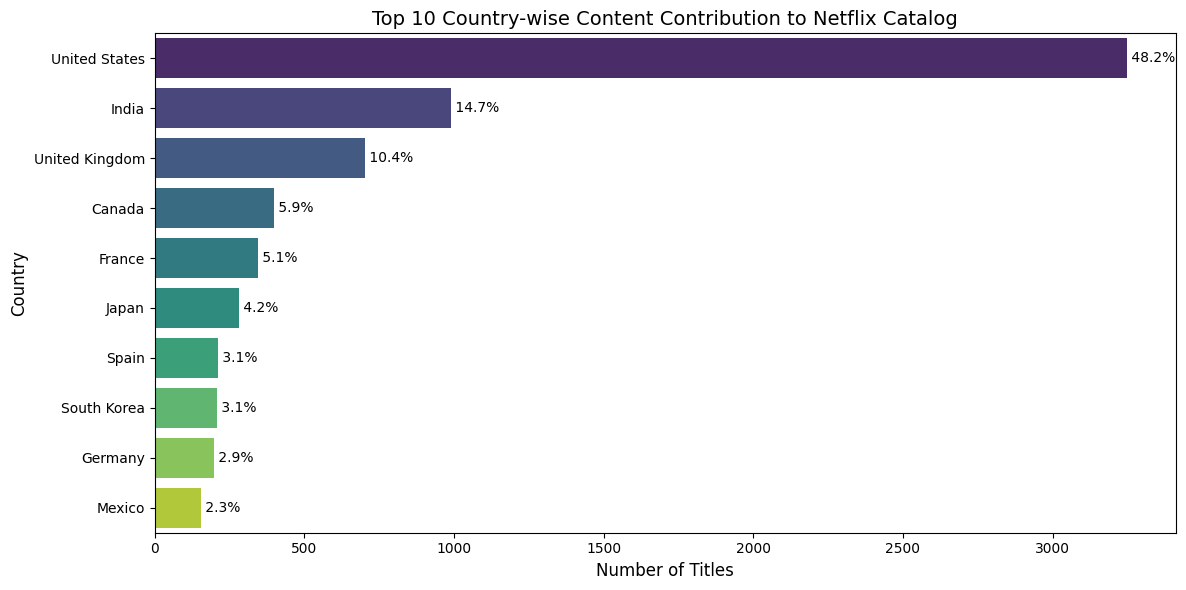

In [80]:
# Visualization: Country-wise content contribution (Bar Chart)
plt.figure(figsize=(12, 6))
sns.barplot(x='Content_Count', y='Country', data=country_contribution_df, palette='viridis')
plt.title('Top 10 Country-wise Content Contribution to Netflix Catalog', fontsize=14)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
# Add percentage labels to bars
for index, row in country_contribution_df.iterrows():
    plt.text(row['Content_Count'], index, f' {row["Percentage"]:.1f}%', va='center')
plt.tight_layout()

In [88]:
# Rating Distribution
rating_counts = df['Rating'].value_counts().nlargest(10)
rating_counts

Rating
TV-MA    2841
TV-14    1904
TV-PG     781
R         665
PG-13     386
TV-Y      273
TV-Y7     267
PG        247
TV-G      186
NR         82
Name: count, dtype: int64

C:\Users\Vidyadheesha M Pandurangi\AppData\Local\Temp\ipykernel_7408\2285464422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='coolwarm')


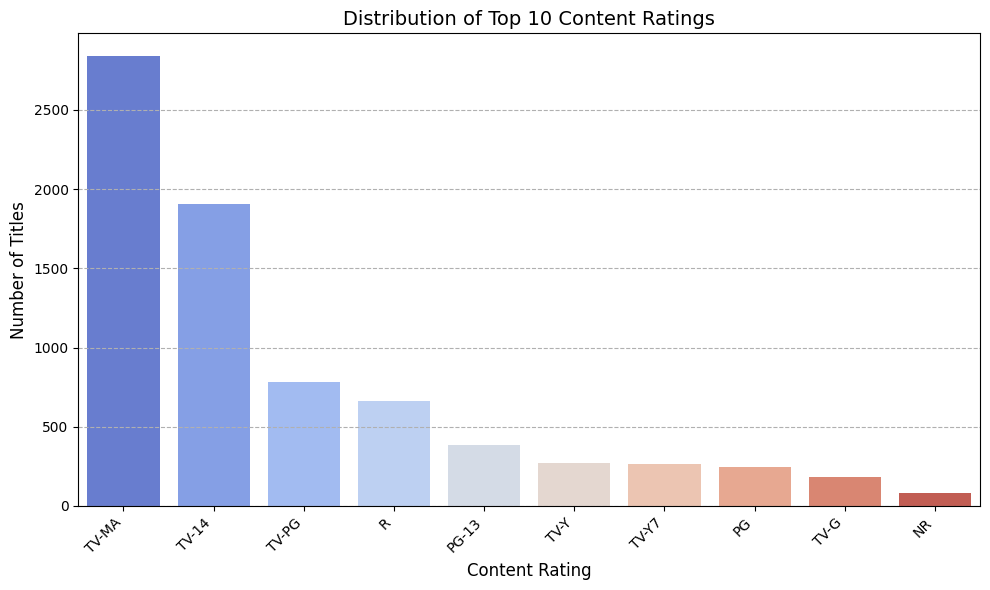

In [84]:
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='coolwarm')
plt.title('Distribution of Top 10 Content Ratings', fontsize=14)
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [92]:
# Graphical Insight 8: TV Show Seasons Trend
tv_shows_df = df[df['Content_Type'] == 'TV Show'].copy()
tv_shows_df['Seasons'] = tv_shows_df['Duration'].str.replace(' Season[s]?', '', regex=True).astype(str)

In [100]:
# Group seasons into categories for trend analysis
def categorize_seasons(seasons):
    if seasons == '1':
        return '1 Season'
    elif seasons in ['2', '3']:
        return '2-3 Seasons'
    elif seasons in ['4', '5']:
        return '4-5 Seasons'
    elif seasons != 'Unknown':
        try:
            if int(seasons) > 5:
                return '6+ Seasons'
        except ValueError:
            return 'Other/Unknown'
    return 'Other/Unknown'

tv_shows_df['Season_Category'] = tv_shows_df['Seasons'].apply(categorize_seasons)

In [102]:
# Calculate annual trend for key categories
season_trend = tv_shows_df[tv_shows_df['Season_Category'].isin(['1 Season', '2-3 Seasons', '4-5 Seasons', '6+ Seasons'])] \
                        .groupby(['Release_Year', 'Season_Category']).size().unstack(fill_value=0)

# Filter for recent years (2010 onwards)
season_trend = season_trend[season_trend.index >= 2010]

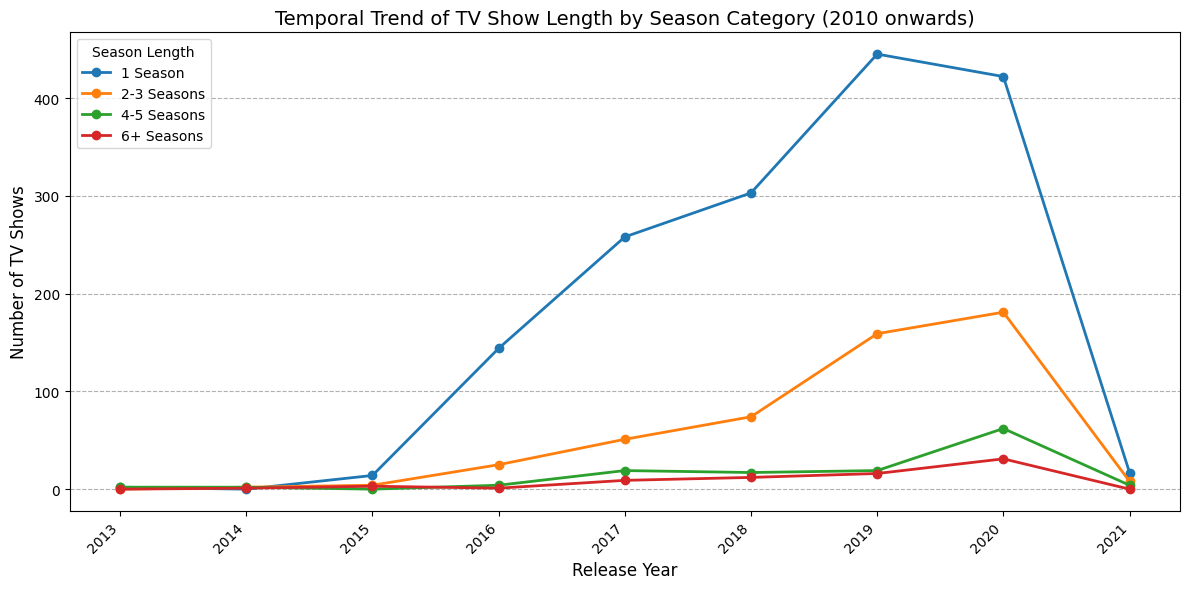

In [104]:
plt.figure(figsize=(12, 6))
season_trend.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())
plt.title('Temporal Trend of TV Show Length by Season Category (2010 onwards)', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)
plt.legend(title='Season Length', loc='upper left')
plt.xticks(season_trend.index, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [106]:
# Top Directors Contribution
known_directors_df = df[df['Director'] != 'Unknown'].copy()
top_10_directors = known_directors_df['Director'].value_counts().nlargest(10)
top_10_directors

Director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Youssef Chahine           12
Martin Scorsese           12
Steven Spielberg          10
David Dhawan               9
Johnnie To                 8
Name: count, dtype: int64

C:\Users\Vidyadheesha M Pandurangi\AppData\Local\Temp\ipykernel_7408\3358407033.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_directors.values, y=top_10_directors.index, palette='magma')


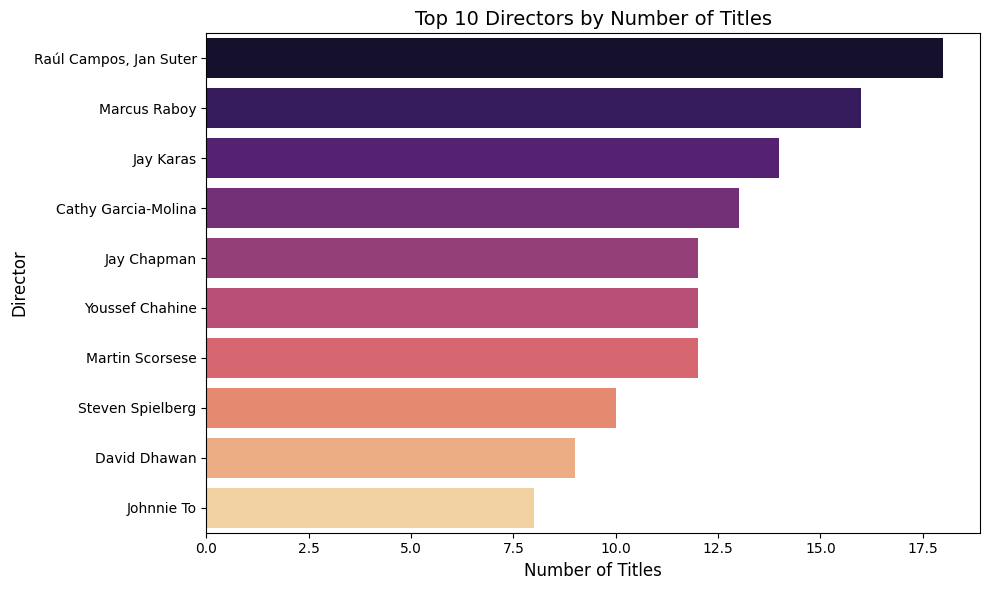

In [108]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_directors.values, y=top_10_directors.index, palette='magma')
plt.title('Top 10 Directors by Number of Titles', fontsize=14)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.tight_layout()